
=== CLASSIFIER PERFORMANCE ===
Accuracy: 0.9343
F1 Score: 0.8434596140100071
                 precision    recall  f1-score   support

           safe       0.94      0.98      0.96      7755
unsafe_tailgate       0.91      0.79      0.84      2245

       accuracy                           0.93     10000
      macro avg       0.92      0.88      0.90     10000
   weighted avg       0.93      0.93      0.93     10000


=== REGRESSOR PERFORMANCE ===
MAE: 1.032900812306432
R2 Score: 0.7754886307368843


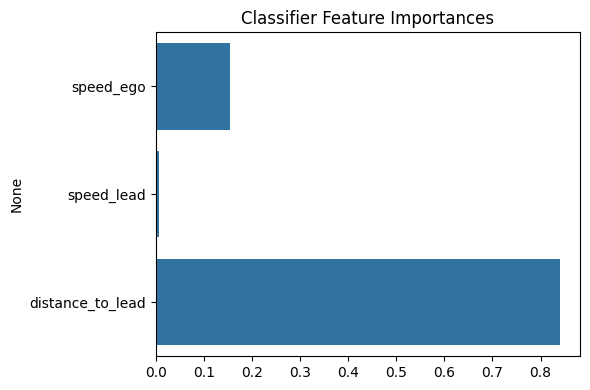

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns


# Generate synthetic dataset
def generate_dataset(n=50000, seed=42):
    np.random.seed(seed)

    # Random realistic driving values
    speed_ego = np.random.uniform(60, 130, n)
    speed_lead = np.random.uniform(40, 140, n)
    time_gap = np.random.uniform(0.4, 6.0, n)

    # Distance approximation from time-gap
    distance_to_lead = (speed_ego / 3.6) * time_gap + np.random.normal(0, 3, n)

    # Base unsafe condition
    unsafe_base = time_gap < 1.5

    # Add randomness to labels
    flip_to_unsafe = np.random.random(n) < 0.05
    flip_to_safe = np.random.random(n) < 0.05

    label = unsafe_base.astype(int)
    label = np.where(flip_to_unsafe, 1, label)
    label = np.where(flip_to_safe, 0, label)

    # Unsafe duration only for unsafe samples
    unsafe_duration = np.zeros(n)
    mask = label == 1

    unsafe_duration[mask] = (
        0.1 * distance_to_lead[mask] +
        0.05 * np.maximum(speed_ego[mask] - speed_lead[mask], 0) +
        np.random.exponential(1.5, mask.sum())
    )

    # Clip extreme values
    unsafe_duration = np.clip(unsafe_duration, 0, 12)

    # Create DataFrame
    df = pd.DataFrame({
        "speed_ego": speed_ego,
        "speed_lead": speed_lead,
        "distance_to_lead": distance_to_lead,
        "unsafe_duration": unsafe_duration,
        "label": label
    })

    return df


# Train a decision tree classifier
def train_classifier(df):
    X = df[['speed_ego', 'speed_lead', 'distance_to_lead']]
    y = df['label']

    # Stratified split keeps label ratio same
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Stable, less overfitting decision tree
    clf = DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        random_state=42
    )

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Evaluation
    print("\n=== CLASSIFIER PERFORMANCE ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print(classification_report(y_test, y_pred, target_names=["safe", "unsafe_tailgate"]))

    return clf, X


# Train a regressor for unsafe duration
def train_regressor(df):
    # Only unsafe samples have non-zero duration
    df_unsafe = df[df['label'] == 1]

    X = df_unsafe[['speed_ego', 'speed_lead', 'distance_to_lead']]
    y = df_unsafe['unsafe_duration']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    reg = DecisionTreeRegressor(
        max_depth=8,
        min_samples_leaf=10,
        random_state=42
    )

    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)

    # Duration regression evaluation
    print("\n=== REGRESSOR PERFORMANCE ===")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))

    return reg


# Plot classifier feature importances
def plot_feature_importances(clf, feature_names):
    plt.figure(figsize=(6, 4))
    sns.barplot(x=clf.feature_importances_, y=feature_names)
    plt.title("Classifier Feature Importances")
    plt.tight_layout()
    plt.show()


# Main execution
if __name__ == "__main__":
    df = generate_dataset()
    clf, X = train_classifier(df)
    reg = train_regressor(df)
    plot_feature_importances(clf, X.columns)
